In [1]:
import os
import sys
import torch
# import logging
import torch.nn as nn
# import torch.nn.functional as F
from torch.utils.data import Dataset,DataLoader
# from torch.autograd import Variable
# import torchvision.models as models

import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from scipy.special import gamma, gammaln

import copy
import datetime
import yaml

import importlib

In [2]:
dirP_str = os.path.join(os.environ['HOME'], 
                    'Python',
                    'aerosol-scattering',
                    'library')
if dirP_str not in sys.path:
    sys.path.append(dirP_str)
    
import evid_nn

In [3]:
model_config = "best_vld_flt1.yml"  # validation and test data are from flights randomly thinned from all HIPPO datasets

In [4]:
config_file = os.path.join(os.environ['HOME'], 
                    'Python',
                    'aerosol-scattering',
                    'config','echo',model_config)

# config_file = os.path.join(os.environ['HOME'], 
#                     'Python',
#                     'aerosol-scattering','scripts','casper',
#                     'echo_config','polynn_model_config.yml')

with open(config_file) as cf:
    conf = yaml.load(cf, Loader=yaml.FullLoader)

In [5]:
def transpose_and_flatten_data_array(da: xr.DataArray,flattened_dim_name:str = None) -> xr.DataArray:
    """
    Transposes an xarray DataArray so the first dimension is 'data_index'
    and all other dimensions are flattened into a single second dimension
    named 'flattened_dims'.

    Args:
        da (xr.DataArray): The input DataArray.

    Returns:
        xr.DataArray: The reshaped DataArray with dimensions ('data_index', 'flattened_dims').
                      The 'flattened_dims' dimension will have a MultiIndex if multiple
                      dimensions were stacked, preserving original coordinate information.
    """

    # --- Handle Scalar DataArray ---
    # If the DataArray is a scalar (no dimensions), expand it to a (1,1) array
    # with the desired dimension names.
    if not da.dims:
        return da.expand_dims({'data_index': 1, 'flattened_dims': 1})

    # --- Prepare Dimensions ---
    original_dims = list(da.dims)
    data_index_dim_name = 'data_index'
    if flattened_dim_name is None:
        flattened_dim_name = 'input_vars'

    # Step 1: Ensure 'data_index' is a dimension and is the first dimension.
    if data_index_dim_name not in original_dims:
        # If 'data_index' is not present, assume the current first dimension
        # should be renamed to 'data_index'.
        first_dim_original_name = original_dims[0]
        da = da.rename({first_dim_original_name: data_index_dim_name})
        # Update the list of original_dims to reflect the rename
        original_dims = list(da.dims)
    
    # Now, 'data_index' is guaranteed to be a dimension in `da`.
    # Ensure 'data_index' is the very first dimension.
    if da.dims[0] != data_index_dim_name:
        # Use .transpose() to move 'data_index' to the first position,
        # keeping the relative order of other dimensions.
        da = da.transpose(data_index_dim_name, *[d for d in da.dims if d != data_index_dim_name])

    # --- Flatten Other Dimensions ---
    # Identify all dimensions that are NOT 'data_index'. These will be flattened.
    dims_to_flatten = [d for d in da.dims if d != data_index_dim_name]

    if not dims_to_flatten:
        # If there are no other dimensions (e.g., the original array was already
        # just ('data_index',)), we need to add a 'flattened_dims' dimension
        # of size 1 to achieve the target 2D structure.
        # We use axis=1 to add it as the second dimension.
        return da.expand_dims(flattened_dim_name, axis=1)

    # Use .stack() to combine the identified dimensions into a single new dimension.
    # xarray's .stack() method automatically creates a MultiIndex for the new dimension,
    # which is excellent for preserving the original coordinate information.
    # The new stacked dimension will be added as the last dimension by default.
    # Since 'data_index' was already moved to the first position, the final order
    # will be (data_index, flattened_dims), which is the desired outcome.
    stacked_da = da.stack({flattened_dim_name: dims_to_flatten})

    return stacked_da

In [6]:
os.path.join(conf['data']['valid_data_path'],conf['data']['valid_data_file'])

'/glade/derecho/scratch/mhayman/aerosol/datasets/hippo_aerosol_training_data_valid.nc'

In [9]:
override_validation = False  # forces the validation data to be split from training

rank = 0
trial = False


device = torch.device(f"cuda:{rank % torch.cuda.device_count()}") if torch.cuda.is_available() else torch.device("cpu")
torch.cuda.set_device(rank % torch.cuda.device_count())
if conf['model']['dtype'] == 'float32':
    dtype = torch.float32
elif conf['model']['dtype'] == 'float64':
    dtype = torch.float64
else:
    dtype = torch.float

# Config settings
# seed = 1000 if "seed" not in conf else conf["seed"]
# seed_everything(seed)


# train_ds = xr.open_dataset(os.path.join(conf['data']['data_path'],conf['data']['data_file']))
ds = xr.open_dataset(os.path.join(conf['data']['data_path'],conf['data']['data_file']))

train_batch_size = conf['data']['batch_size']
valid_batch_size = conf['data']['batch_size']
test_batch_size = conf['data']['batch_size']

train_idx = int(np.round(ds.sizes['data_index']*conf['data']['train_fraction']))
valid_idx = train_idx+int(np.round(ds.sizes['data_index']*conf['data']['valid_fraction']))
test_idx = train_idx+int(np.round(ds.sizes['data_index']*conf['data']['test_fraction']))

# ds = train_ds

input_lst = []
input_str_lst = []
for var in conf['data']['wavelength_inputs']:
    for wl in conf['data']['wavelength_inputs'][var]['wavelength_lst']:
        input_lst.append(transpose_and_flatten_data_array(ds[var].sel(wavelength=wl)))
        input_str_lst.append(var+f"_{int(wl*1e9)}")
for var in conf['data']['input_cols']:
    input_lst.append(transpose_and_flatten_data_array(ds[var],flattened_dim_name='input_vars'))
    input_str_lst.append(var)

# train_input_arr = xr.concat(input_lst,'input_vars')
train_input_arr = xr.concat(input_lst,pd.Index(input_str_lst,name='input_vars'))

output_lst = []
output_str_lst = []
for var in conf['data']['output_cols']:
    output_lst.append(transpose_and_flatten_data_array(ds[var],flattened_dim_name='label_vars'))
    output_str_lst.append(var)

train_label_arr = xr.concat(output_lst,pd.Index(conf['data']['output_cols'],name='label_vars'))

x_scaler = evid_nn.rescale(0,1,axes=(0,))
y_scaler = evid_nn.rescale(0,1,axes=(0,))

x_scaler.set_scale(np.log(train_input_arr.values))
y_scaler.set_scale(np.log(train_label_arr.values))

# try:
if not override_validation:
    valid_ds = xr.open_dataset(os.path.join(conf['data']['valid_data_path'],conf['data']['valid_data_file']))
    input_lst = []
    # input_str_lst = []
    for var in conf['data']['wavelength_inputs']:
        for wl in conf['data']['wavelength_inputs'][var]['wavelength_lst']:
            input_lst.append(transpose_and_flatten_data_array(valid_ds[var].sel(wavelength=wl)))
            # input_str_lst.append(var+f"_{int(wl*1e9)}")
    for var in conf['data']['input_cols']:
        input_lst.append(transpose_and_flatten_data_array(valid_ds[var],flattened_dim_name='input_vars'))
        # input_str_lst.append(var)
    
    # train_input_arr = xr.concat(input_lst,'input_vars')
    valid_input_arr = xr.concat(input_lst,pd.Index(input_str_lst,name='input_vars'))
    
    output_lst = []
    # output_str_lst = []
    for var in conf['data']['output_cols']:
        output_lst.append(transpose_and_flatten_data_array(valid_ds[var],flattened_dim_name='label_vars'))
        # output_str_lst.append(var)
    
    valid_label_arr = xr.concat(output_lst,pd.Index(conf['data']['output_cols'],name='label_vars'))
    
    x_train = x_scaler.scale(np.log(train_input_arr.values))
    x_valid = x_scaler.scale(np.log(valid_input_arr.values))
    
    y_train = y_scaler.scale(np.log(train_label_arr.values))
    y_valid = y_scaler.scale(np.log(valid_label_arr.values))
# except Exception as E:
else:
    print("validation dataset encountered an error:")
    print("override_validation=True, so validation is split from training data")
    # print(str(E))
    x_train = x_scaler.scale(np.log(train_input_arr.values[:train_idx,:]))
    x_valid = x_scaler.scale(np.log(train_input_arr.values[train_idx:valid_idx,:]))
    
    y_train = y_scaler.scale(np.log(train_label_arr.values[:train_idx,:]))
    y_valid = y_scaler.scale(np.log(train_label_arr.values[train_idx:valid_idx,:]))
    
# x_train = x_scaler.scale(np.log(train_input_arr.values[:train_idx,:]))
# x_valid = x_scaler.scale(np.log(train_input_arr.values[train_idx:valid_idx,:]))
# x_test = x_scaler.scale(np.log(train_input_arr.values[valid_idx:,:]))


# y_train = y_scaler.scale(np.log(train_label_arr.values[:train_idx,:]))
# y_valid = y_scaler.scale(np.log(train_label_arr.values[train_idx:valid_idx,:]))
# y_test = y_scaler.scale(np.log(train_label_arr.values[valid_idx:,:]))

# cond_args = {
#     'in_norm_arr':1,
#     'in_bias_arr':0,
#     'out_norm_arr':1,
#     'out_bias_arr':0,
# }

cond_args = conf['data']['cond_args']

train_dataset = evid_nn.EvidDataset(x_train,y_train,
                            dtype=dtype,device=device,
                            **cond_args)
valid_dataset = evid_nn.EvidDataset(x_valid,y_valid,
                            dtype=dtype,device=device,
                            **cond_args)
# test_dataset = evid_nn.EvidDataset(x_test,y_test,
#                             dtype=dtype,device=device,
#                             **cond_args)

train_dataloader = DataLoader(train_dataset, batch_size=train_batch_size, shuffle=True)
valid_dataloader = DataLoader(valid_dataset, batch_size=valid_batch_size, shuffle=True)
# test_dataloader = DataLoader(test_dataset, batch_size=test_batch_size, shuffle=False)

In [10]:
test_ds = xr.open_dataset(os.path.join(conf['data']['test_data_path'],conf['data']['test_data_file']))
input_lst = []
# input_str_lst = []
for var in conf['data']['wavelength_inputs']:
    for wl in conf['data']['wavelength_inputs'][var]['wavelength_lst']:
        input_lst.append(transpose_and_flatten_data_array(test_ds[var].sel(wavelength=wl)))
for var in conf['data']['input_cols']:
    input_lst.append(transpose_and_flatten_data_array(test_ds[var],flattened_dim_name='input_vars'))

test_input_arr = xr.concat(input_lst,pd.Index(input_str_lst,name='input_vars'))

output_lst = []
for var in conf['data']['output_cols']:
    output_lst.append(transpose_and_flatten_data_array(test_ds[var],flattened_dim_name='label_vars'))

test_label_arr = xr.concat(output_lst,pd.Index(conf['data']['output_cols'],name='label_vars'))

x_test = x_scaler.scale(np.log(test_input_arr.values))

y_test = y_scaler.scale(np.log(test_label_arr.values))

test_dataset = evid_nn.EvidDataset(x_test,y_test,
                            dtype=dtype,device=device,
                            **cond_args)

test_dataloader = DataLoader(test_dataset, batch_size=test_batch_size, shuffle=False)

In [15]:
# in_data = x_train
# out_label = y_train

# in_data = x_valid
# out_label = y_valid

in_data = x_test
out_label = y_test

hist_width = 0.01

# # TODO this should only sample from test data, but the histogram data should use all the data
# # idx = 1834
# # idx = 131398
# # idx = 974538
# # idx = 49570 # bimodal
# # idx = 886401
# # idx = 714798
# # idx= 0
# idx = int(np.random.rand()*in_data.shape[0])  # get random input


# print(f"index: {idx}")

# hist_in_data = x_train
# hist_out_label = y_train

# # get histogram data.  This should sample from all of the data (not just test data)
# sim_idx = np.where(np.prod(np.abs(hist_in_data - in_data[idx,:].reshape(1,-1)) < hist_width,axis=1))
# # r_sim = out_label[:,1][sim_idx]
# # n_sim = out_label[:,0][sim_idx]

# r_sim_hist = hist_out_label[:,1][sim_idx]
# n_sim_hist = hist_out_label[:,0][sim_idx]

# r_act = out_label[:,1][idx]
# n_act = out_label[:,0][idx]

In [12]:
conf_reload, model_reload = evid_nn.load_poly_nn_model("20250801T145347",name_str='hyper_best',dtype=dtype,device=device)
x_scaler_r = evid_nn.rescale(0,1)
x_scaler_r.set_config(**conf_reload['save_model']['x_scaler'])
y_scaler_r = evid_nn.rescale(0,1)
y_scaler_r.set_config(**conf_reload['save_model']['y_scaler'])

loading model from 
/glade/u/home/mhayman/Python/aerosol-scattering/models


In [17]:
in_data.shape

(90683, 6)

In [114]:
batch_size = 128
ensemble_size = 100
ensemble_width = 0.01 # (observation uncertainty)
batch_count = in_data.shape[0]//batch_size

r_centroid_lst = []
n_centroid_lst = []
r_centroid_ens_lst = []
n_centroid_ens_lst = []
r_act_lst = []
n_act_lst = []
p_model_lst = []

for batch in range(batch_count):
    input_batch = torch.tensor(in_data[batch*batch_size:((batch+1)*batch_size),:], dtype=dtype, device=device)
    
    f_pdf_tnsr = model_reload.output_pdf(input_batch)
    f_pdf = f_pdf_tnsr.detach().cpu().numpy()
    x_plt = model_reload.x_int.detach().cpu().numpy()
    dx2 = (model_reload.dx_int**2).detach().cpu().numpy()

    r_centroid_lst.append(torch.sum(model_reload.x_int.detach().reshape(1,1,-1)*f_pdf_tnsr*model_reload.dx_int**2,dim=(1,2)).detach().cpu().numpy())
    n_centroid_lst.append(torch.sum(model_reload.x_int.detach().reshape(1,-1,1)*f_pdf_tnsr*model_reload.dx_int**2,dim=(1,2)).detach().cpu().numpy())

    r_act_lst.append(out_label[batch*batch_size:((batch+1)*batch_size),1])
    n_act_lst.append(out_label[batch*batch_size:((batch+1)*batch_size),0])

    fit_coef = model_reload.net(input_batch)
    p_model = model_reload.fpdf(fit_coef, input_batch)
    p_model_lst.append(p_model.detach().cpu().numpy())
    
    ensemble_size = 100
    ensemble_width = hist_width # (observation uncertainty)
    loop_length = 10
    f_pdf_ens = np.zeros((f_pdf.shape[1],f_pdf.shape[2]))
    for ens_group_idx in range(loop_length):
        f_pdf_ens_tnsr = model_reload.output_pdf(torch.tensor(in_data[batch*batch_size:((batch+1)*batch_size),:]+(np.random.rand(batch_size,in_data.shape[1])*2-1)*ensemble_width,dtype=dtype,device=device))
        f_pdf_ens += np.sum(f_pdf_ens_tnsr.detach().cpu().numpy(),axis=0)
        # print(ens_group_idx)
    
    f_pdf_ens = f_pdf_ens/(loop_length*ensemble_size)

    r_centroid_ens_lst.append(np.sum(np.sum(x_plt.reshape(1,1,-1)*f_pdf_ens*dx2,axis=2),axis=1))
    n_centroid_ens_lst.append(np.sum(np.sum(x_plt.reshape(1,-1,1)*f_pdf_ens*dx2,axis=2),axis=1))

In [51]:
dx2 = (model_reload.dx_int**2).detach().cpu().numpy()

In [39]:
f_pdf_tnsr.shape

torch.Size([128, 1000, 1000])

In [35]:
model_reload.x_int.detach().shape

torch.Size([1000])

In [41]:
batch

707

In [37]:
input_batch.shape

torch.Size([128, 6])

ValueError: x and y must be the same size

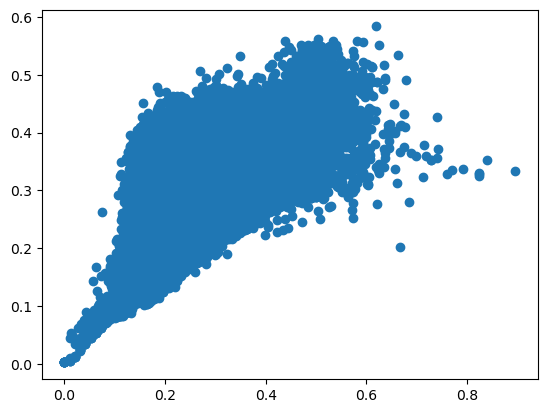

In [115]:
plt.figure()
plt.scatter(np.concatenate(r_act_lst),np.concatenate(r_centroid_lst))
plt.scatter(np.concatenate(r_act_lst),np.concatenate(r_centroid_ens_lst))

Text(0.5, 0, '$Log_{10}$ Number density difference')

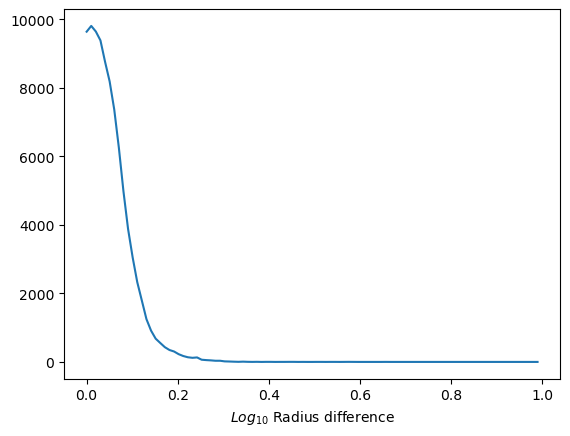

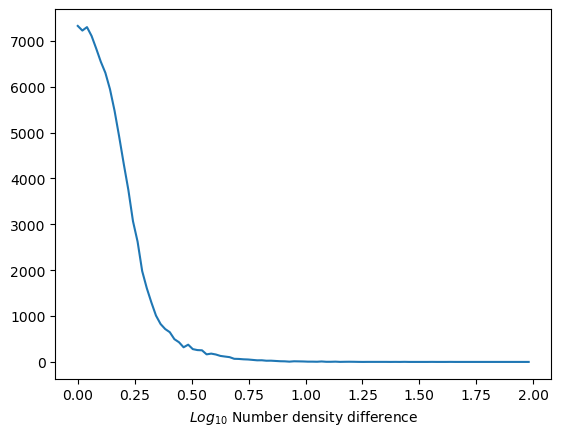

In [100]:
act_data_ln = y_scaler.unscale(np.stack([np.concatenate(n_act_lst),np.concatenate(r_act_lst)],axis=1))
centroid_data_ln = y_scaler.unscale(np.stack([np.concatenate(n_centroid_lst),np.concatenate(r_centroid_lst)],axis=1))
# r_data = np.abs(np.concatenate(r_act_lst)-np.concatenate(r_centroid_lst)*dx2)
# n_data = np.abs(np.concatenate(n_act_lst)-np.concatenate(n_centroid_lst)*dx2)
# hr = np.histogram(r_data,bins=np.linspace(0,1,100))
# hn = np.histogram(n_data,bins=np.linspace(0,1,100))
# hist_ax = y_scaler.unscale(np.stack([hn[1],hr[1]],axis=1))

hr = np.histogram(np.abs(act_data_ln[:,1]-centroid_data_ln[:,1])*np.log10(np.exp(1)),bins=np.linspace(0,1,100))
plt.figure()
plt.plot(hr[1][:-1],hr[0])
plt.xlabel('$Log_{10}$ Radius difference')

hn = np.histogram(np.abs(act_data_ln[:,0]-centroid_data_ln[:,0])*np.log10(np.exp(1)),bins=np.linspace(0,2,100))
plt.figure()
plt.plot(hn[1][:-1],hn[0])
plt.xlabel('$Log_{10}$ Number density difference')

Text(0.5, 1.0, 'Deviation from Centroid')

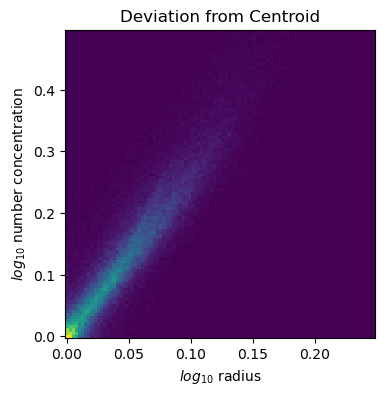

In [111]:
hcmb = np.histogram2d(np.abs(act_data_ln[:,1]-centroid_data_ln[:,1])*np.log10(np.exp(1)),
                    np.abs(act_data_ln[:,0]-centroid_data_ln[:,0])*np.log10(np.exp(1)),
                    bins=(np.linspace(0,0.25,100),np.linspace(0,0.5,100)))

fig,ax = plt.subplots(1,1,figsize=(4,4))

ax.pcolormesh(hcmb[1][:-1],hcmb[2][:-1],hcmb[0].T/np.sum(hcmb[0]))
xl = ax.get_xlim()
yl = ax.get_ylim()
# contours = ax[0].contour(pdf_ax[:,1],pdf_ax[:,0], f_pdf[0,...], levels = 1, colors='white', linestyles=':', linewidths=1)
# ax.scatter(act_ax[1],act_ax[0],c='tab:red',marker='x',)
# ax.set_xscale('log')
# ax.set_yscale('log')
# ax.set_xlim(xl)
# ax.set_ylim(yl)
ax.set_xlabel(r'$log_{10}$ radius')
ax.set_ylabel(r'$log_{10}$ number concentration')
ax.set_title('Deviation from Centroid')

In [99]:
(act_data_ln[:,0]-centroid_data_ln[:,0])

array([ 1.18966267, -0.0618497 , -0.26183775, ...,  0.94528501,
        0.65844917,  0.65663844])

(0.0, 1e-09)

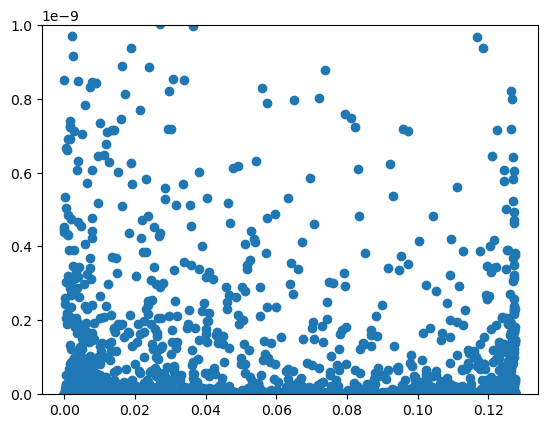

In [69]:
h_interp = np.interp(r_data, hr[1][:-1], hr[0]/np.sum(hr[0]))
plt.figure()
plt.scatter(h_interp,np.concatenate(p_model_lst)*dx2)
# plt.xlim([0,0.1])
plt.ylim([0,1e-9])
# plt.yscale('log')

In [50]:
torch.sum(f_pdf_tnsr,dim=(1,2))*model_reload.dx_int**2

tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 

In [48]:
f_pdf_tnsr*model_reload.dx_int

TypeError: only integer tensors of a single element can be converted to an index

In [47]:
model_reload.dx_int

tensor(0.0010, device='cuda:0', dtype=torch.float64)